<a href="https://colab.research.google.com/github/kyungeunvoyage/NailFoldExp/blob/main/AbsoluteThreshold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

In [11]:
# 파일 리스트 (본인의 파일명에 맞게 수정)
file_names = ['Tactile_S03.csv']
data_list = []

for file in file_names:
    try:
        temp_df = pd.read_csv(file)
        data_list.append(temp_df)
    except FileNotFoundError:
        print(f"⚠️ 파일을 찾을 수 없습니다: {file}")

# 데이터 통합
if data_list:
    df = pd.concat(data_list, ignore_index=True)

    # 1. Condition 명칭 변경 (Active -> On-touch)
    df['Condition'] = df['Condition'].replace('Active', 'On-touch')

    # 2. 분석 대상 구역 필터링 (Area A, B, C)
    df = df[df['Area'].isin(['A', 'B', 'C'])]

    # 3. Force 문자열에서 숫자만 추출 (예: '0.07g' -> 0.07)
    df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)

    print("✅ 데이터 로드 및 전처리 완료")
else:
    print("❌ 로드된 데이터가 없습니다.")

✅ 데이터 로드 및 전처리 완료


<>:23: SyntaxWarning: invalid escape sequence '\d'
<>:23: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_307/110365086.py:23: SyntaxWarning: invalid escape sequence '\d'
  df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)


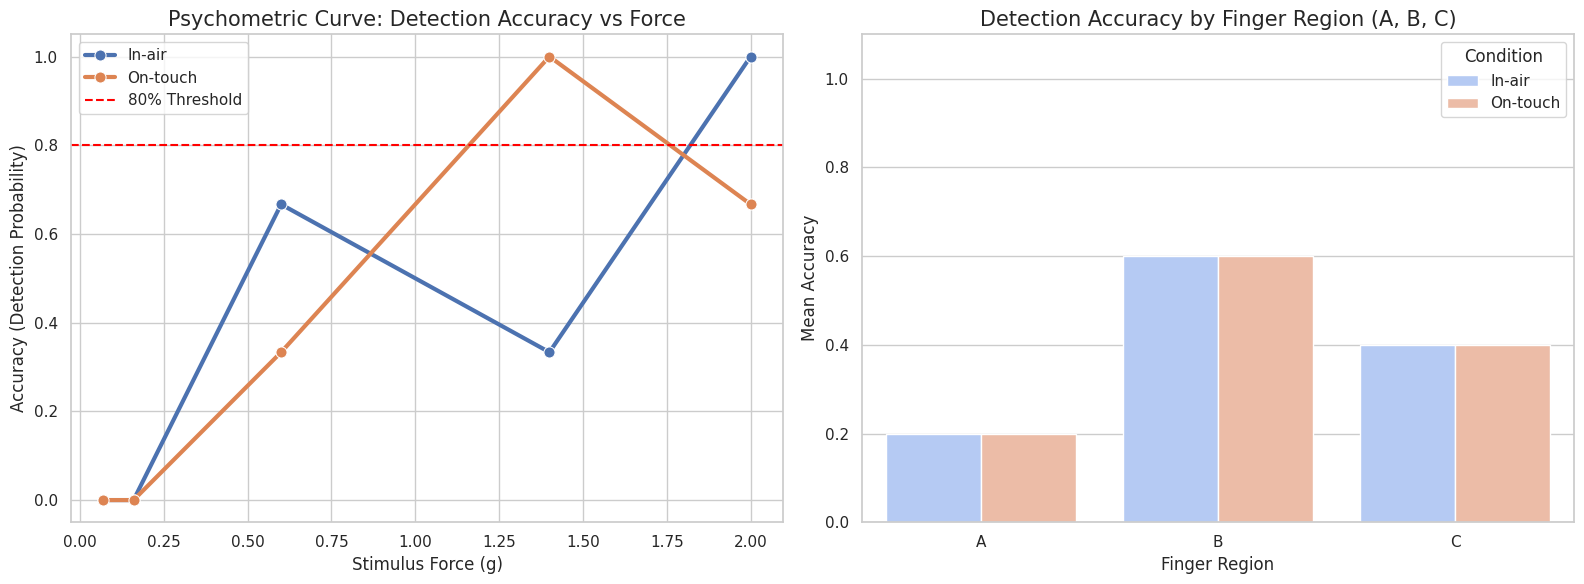

In [12]:
# 1. 전반적인 강도별 정답률 계산 (Psychometric Curve용)
overall_acc = df.groupby(['Condition', 'Force_Val'])['IsCorrect'].mean().reset_index()

# 2. 구역별(Area) 평균 정답률 계산 (Bar Chart용)
area_acc = df.groupby(['Condition', 'Area'])['IsCorrect'].mean().reset_index()

# 그래프 그리기
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (Left) Psychometric Curve
sns.lineplot(ax=axes[0], data=overall_acc, x='Force_Val', y='IsCorrect',
             hue='Condition', marker='o', linewidth=3, markersize=8)
axes[0].axhline(0.8, color='red', linestyle='--', label='80% Threshold')
axes[0].set_title('Psychometric Curve: Detection Accuracy vs Force', fontsize=15)
axes[0].set_xlabel('Stimulus Force (g)', fontsize=12)
axes[0].set_ylabel('Accuracy (Detection Probability)', fontsize=12)
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()

# (Right) Regional Accuracy
sns.barplot(ax=axes[1], data=area_acc, x='Area', y='IsCorrect',
            hue='Condition', order=['A', 'B', 'C'], palette='coolwarm')
axes[1].set_title('Detection Accuracy by Finger Region (A, B, C)', fontsize=15)
axes[1].set_xlabel('Finger Region', fontsize=12)
axes[1].set_ylabel('Mean Accuracy', fontsize=12)
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

In [13]:
print("="*40)
print("       [SUMMARY STATISTICS]       ")
print("="*40)

# 역치 산출 (정답률 80% 기준 최소 강도)
print("\n1. Estimated Absolute Thresholds (80% Accuracy):")
for cond in overall_acc['Condition'].unique():
    cond_df = overall_acc[overall_acc['Condition'] == cond]
    threshold_df = cond_df[cond_df['IsCorrect'] >= 0.8]

    if not threshold_df.empty:
        threshold = threshold_df['Force_Val'].min()
        print(f" - {cond}: {threshold}g")
    else:
        print(f" - {cond}: 80% 정답률에 도달하지 못함")

# 구역별 상세 정답률 출력
print("\n2. Regional Accuracy Table:")
pivot_area = area_acc.pivot(index='Area', columns='Condition', values='IsCorrect')
print(pivot_area)

# 강도별 상세 정답률 출력
print("\n3. Force-wise Accuracy Table:")
pivot_force = overall_acc.pivot(index='Force_Val', columns='Condition', values='IsCorrect')
print(pivot_force)

       [SUMMARY STATISTICS]       

1. Estimated Absolute Thresholds (80% Accuracy):
 - In-air: 2.0g
 - On-touch: 1.4g

2. Regional Accuracy Table:
Condition  In-air  On-touch
Area                       
A             0.2       0.2
B             0.6       0.6
C             0.4       0.4

3. Force-wise Accuracy Table:
Condition    In-air  On-touch
Force_Val                    
0.07       0.000000  0.000000
0.16       0.000000  0.000000
0.60       0.666667  0.333333
1.40       0.333333  1.000000
2.00       1.000000  0.666667
